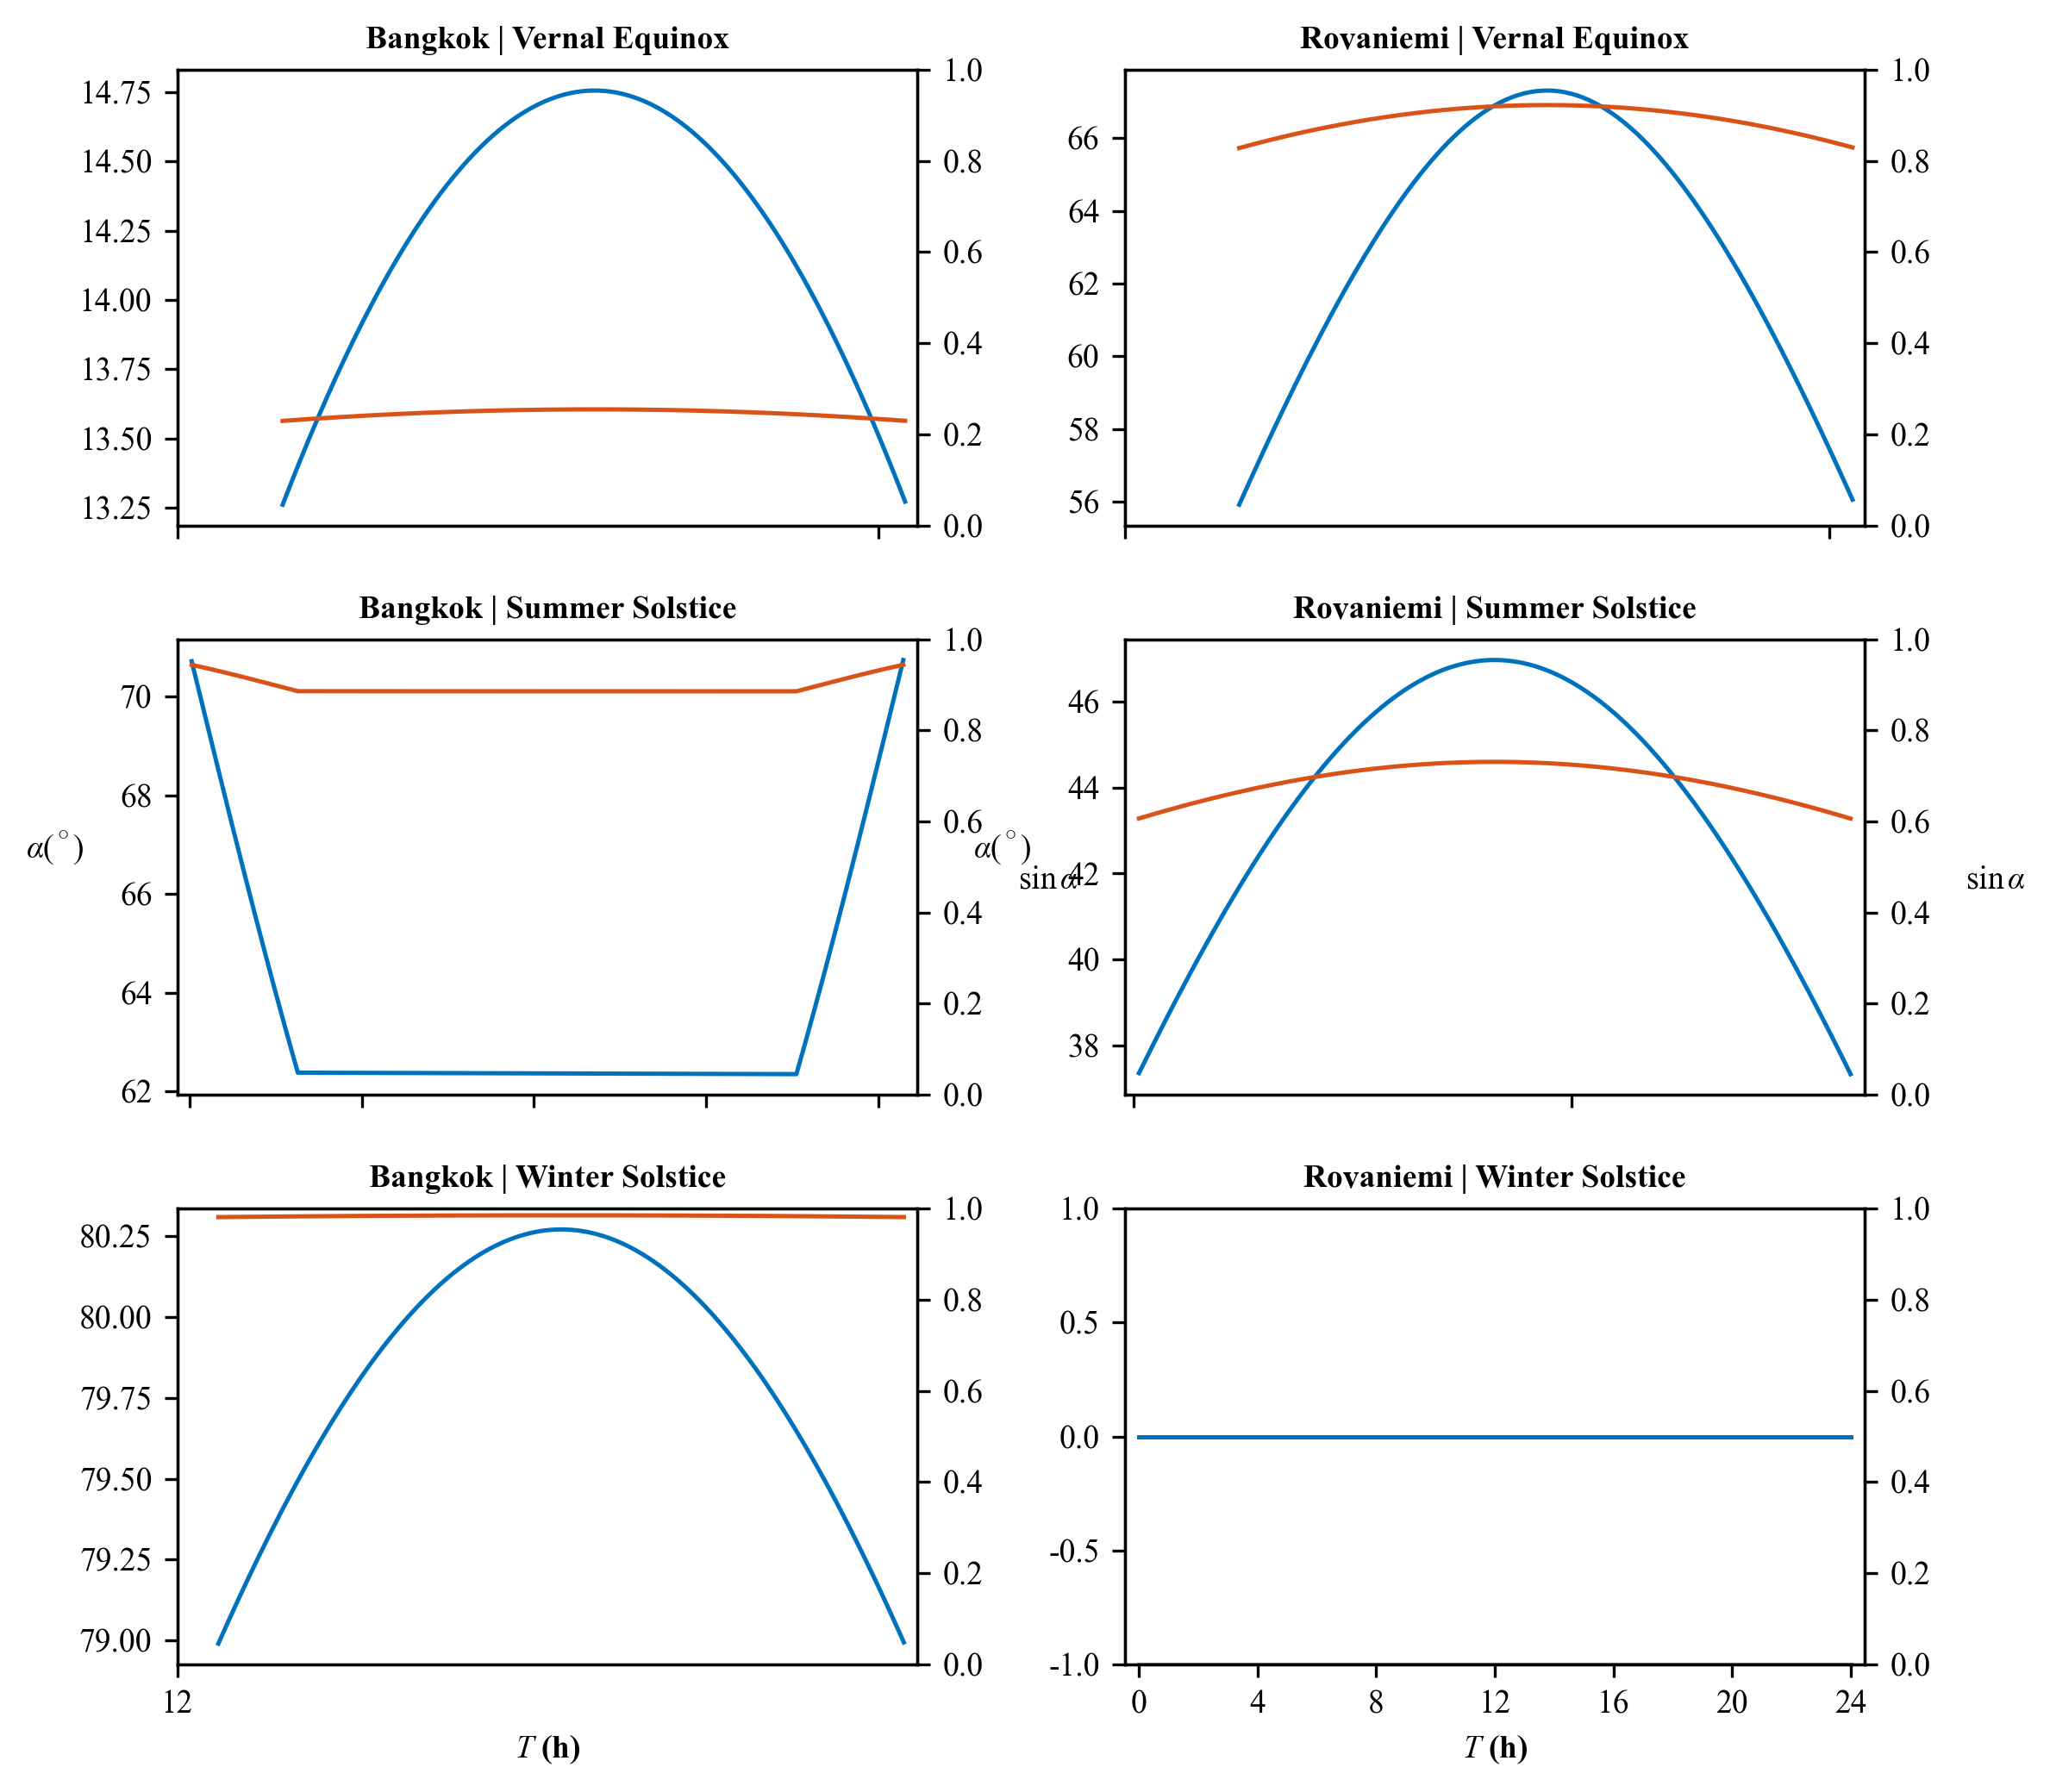

In [13]:
import math
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np

# ===================== IEEE 全局绘图配置 =====================
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.sans-serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
plt.rcParams['font.size'] = 9
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (8, 7)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.alpha'] = 0.2
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['lines.linewidth'] = 1.2

COLOR_ANGLE = '#0072BD'
COLOR_SIN = '#D95319'

def calculate_sun_position(date_time: datetime, lat: float, lng: float) -> dict:
    PI = math.pi
    RAD = PI / 180.0
    DAY_MS = 1000 * 60 * 60 * 24
    J1970 = 2451545.0
    J2000 = 2451545.0
    EARTH_OBLIQUITY = 23.4397 * RAD

    def to_julian(dt: datetime) -> float:
        timestamp_ms = dt.timestamp() * 1000
        return timestamp_ms / DAY_MS - 0.5 + J1970

    def to_days(dt: datetime) -> float:
        return to_julian(dt) - J2000

    def right_ascension(l: float, b: float) -> float:
        return math.atan2(math.sin(l) * math.cos(EARTH_OBLIQUITY) - math.tan(b) * math.sin(EARTH_OBLIQUITY), math.cos(l))

    def declination(l: float, b: float) -> float:
        return math.asin(math.sin(b) * math.cos(EARTH_OBLIQUITY) + math.cos(b) * math.cos(EARTH_OBLIQUITY) * math.sin(l))

    def azimuth(H: float, phi: float, dec: float) -> float:
        return math.atan2(math.sin(H), math.cos(H) * math.sin(phi) - math.tan(dec) * math.cos(phi))

    def altitude(H: float, phi: float, dec: float) -> float:
        return math.asin(math.sin(phi) * math.sin(dec) + math.cos(phi) * math.cos(dec) * math.cos(H))

    def sidereal_time(d: float, lw: float) -> float:
        return RAD * (280.16 + 360.9856235 * d) - lw

    def solar_mean_anomaly(d: float) -> float:
        return RAD * (357.5291 + 0.98560028 * d)

    def ecliptic_longitude(M: float) -> float:
        C = RAD * (1.9148 * math.sin(M) + 0.02 * math.sin(2 * M) + 0.0003 * math.sin(3 * M))
        P = RAD * 102.9372
        return M + C + P + PI

    def sun_coords(d: float) -> dict:
        M = solar_mean_anomaly(d)
        L = ecliptic_longitude(M)
        return {'dec': declination(L, 0.0), 'ra': right_ascension(L, 0.0)}

    lw = RAD * -lng
    phi = RAD * lat
    d = to_days(date_time)
    sun_c = sun_coords(d)
    H = sidereal_time(d, lw) - sun_c['ra']
    az_rad = azimuth(H, phi, sun_c['dec'])
    alt_rad = altitude(H, phi, sun_c['dec'])

    az_deg = (math.degrees(az_rad) + 180) % 360
    alt_deg = math.degrees(alt_rad)
    return {'solar_azimuth_deg': az_deg, 'solar_altitude_deg': alt_deg}

def calculate_wall_angle_and_sin(h_deg: float, A_deg: float) -> tuple:
    if h_deg < 0:
        return 0.0, 0.0
    h_rad = math.radians(h_deg)
    A_rad = math.radians(A_deg)
    sin_theta = abs(math.cos(h_rad) * math.cos(A_rad))
    sin_theta = max(min(sin_theta, 1.0), 0.0)
    theta_deg = math.degrees(math.asin(sin_theta))
    return theta_deg, sin_theta

def moving_average_smooth(data, window_size=3):
    if window_size < 2 or len(data) < window_size:
        return data
    pad_data = [data[0]] * (window_size // 2) + data + [data[-1]] * (window_size // 2)
    return [np.mean(pad_data[i:i + window_size]) for i in range(len(data))]

def compute_daily_curve(target_date: datetime, lat: float, lng: float):
    min_step = 1
    x_hours = np.arange(0, 24, min_step / 60)
    wall_angle_list = []
    sin_theta_list = []

    for hour in x_hours:
        ih = int(np.floor(hour))
        im = int(round((hour - ih) * 60))
        if im == 60:
            ih += 1
            im = 0
        current_time = datetime(target_date.year, target_date.month, target_date.day, ih, im, 0)
        sun = calculate_sun_position(current_time, lat, lng)
        ang, sin_v = calculate_wall_angle_and_sin(sun['solar_altitude_deg'], sun['solar_azimuth_deg'])
        wall_angle_list.append(ang)
        sin_theta_list.append(sin_v)

    # 平滑数据
    ang_smooth = moving_average_smooth(wall_angle_list)
    sin_smooth = moving_average_smooth(sin_theta_list)

    ang_arr = np.array(ang_smooth)
    sin_arr = np.array(sin_smooth)
    x_arr = np.array(x_hours)

    # ===================== 步骤1：过滤基础无效0值段 =====================
    valid_mask_base = ang_arr > 1.0
    x_valid_base = x_arr[valid_mask_base]
    ang_valid_base = ang_arr[valid_mask_base]
    sin_valid_base = sin_arr[valid_mask_base]

    if len(x_valid_base) == 0:
        return np.array([0, 24]), np.array([0.0, 0.0]), np.array([0.0, 0.0])

    # ===================== 步骤2：提取核心高值区间（彻底丢弃阶跃低数值） =====================
    # 70%分位数阈值，只保留前30%高值数据
    high_threshold = np.percentile(ang_valid_base, 70)
    core_high_mask = ang_valid_base >= high_threshold

    x_core_high = x_valid_base[core_high_mask]
    ang_core_high = ang_valid_base[core_high_mask]
    sin_core_high = sin_valid_base[core_high_mask]
    

    if len(x_core_high) == 0:
        return x_valid_base, ang_valid_base, sin_valid_base

    # ===================== 步骤3：纯NumPy提取最长连续高值段（修复长度不匹配bug，无scipy依赖） =====================
    # 计算连续True的区间
    diff_mask = np.diff(np.concatenate(([False], core_high_mask, [False])))
    start_indices = np.where(diff_mask == True)[0]
    end_indices = np.where(diff_mask == False)[0] - 1
    # 新增：如果区间不匹配，直接返回核心高值数据（兜底）
    if len(start_indices) != len(end_indices):
        return x_core_high, ang_core_high, sin_core_high

    if len(start_indices) == 0 or len(end_indices) == 0:
        return x_core_high, ang_core_high, sin_core_high

    # 计算每个连续区间的长度
    # 只保留长度匹配的区间（解决形状不匹配）
    min_len = min(len(start_indices), len(end_indices))
    start_indices = start_indices[:min_len]
    end_indices = end_indices[:min_len]
    segment_lengths = end_indices - start_indices + 1
    # 找到最长区间的索引
    longest_segment_idx = np.argmax(segment_lengths)

    # 提取最长连续区间的掩码
    start_long = start_indices[longest_segment_idx]
    end_long = end_indices[longest_segment_idx]
    longest_mask = np.zeros_like(core_high_mask, dtype=bool)
    longest_mask[start_long:end_long+1] = True

    # ===================== 步骤4：索引匹配（长度一致，无报错） =====================
    x_final = x_core_high[longest_mask]
    ang_final = ang_core_high[longest_mask]
    sin_final = sin_core_high[longest_mask]

    # 兜底：确保返回有效数据
    if len(x_final) == 0:
        return x_core_high, ang_core_high, sin_core_high

    return x_final, ang_final, sin_final

def plot_six_subplots():
    cities = {
        'Bangkok': {
            'lat': 13.75,
            'lng': 100.50,
            'vernal_equinox': datetime(2024, 3, 20),
            'summer_solstice': datetime(2024, 6, 21),
            'winter_solstice': datetime(2024, 12, 21)
        },
        'Rovaniemi': {
            'lat': 66.50,
            'lng': 25.74,
            'vernal_equinox': datetime(2024, 3, 20),
            'summer_solstice': datetime(2024, 6, 21),
            'winter_solstice': datetime(2024, 12, 21)
        }
    }
    seasons = ['vernal_equinox', 'summer_solstice', 'winter_solstice']
    season_labels = {
        'vernal_equinox': 'Vernal Equinox',
        'summer_solstice': 'Summer Solstice',
        'winter_solstice': 'Winter Solstice'
    }

    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(8, 7), dpi=300)
    axes_flat = axes.flatten()

    idx = 0
    for season in seasons:
        for city_name, para in cities.items():
            ax_main = axes_flat[idx]
            lat = para['lat']
            lng = para['lng']
            target_dt = para[season]
            seas_label = season_labels[season]

            # 获取核心高值有效数据（无报错，彻底丢弃阶跃低数值）
            x_valid, ang_valid, sin_valid = compute_daily_curve(target_dt, lat, lng)

            ax_twin = ax_main.twinx()

            # 绘制核心高值区间曲线，无任何多余低数值内容
            ax_main.plot(x_valid, ang_valid, color=COLOR_ANGLE, linestyle='-', marker='')
            ax_twin.plot(x_valid, sin_valid, color=COLOR_SIN, linestyle='-', marker='')

            # ===================== 纵轴完全贴合核心高值区间，无空白 =====================
            ang_min, ang_max = ang_valid.min(), ang_valid.max()
            y_margin = (ang_max - ang_min) * 0.05 if (ang_max - ang_min) > 0 else 1.0
            ax_main.set_ylim(ang_min - y_margin, ang_max + y_margin)
            ax_twin.set_ylim(0.0, 1.0)

            # 横轴贴合核心高值的时间区间，更聚焦
            x_min, x_max = x_valid.min(), x_valid.max()
            x_margin = (x_max - x_min) * 0.02
            ax_main.set_xlim(x_min - x_margin, x_max + x_margin)
            ax_main.set_xticks(np.arange(np.floor(x_min), np.ceil(x_max)+1, 4))

            # 子图标题
            ax_main.set_title(f'{city_name} | {seas_label}', fontsize=9, fontweight='bold', pad=6)

            # 标签规则
            if idx in (4, 5):
                ax_main.set_xlabel(r'$T$ (h)', fontweight='bold')
            else:
                ax_main.set_xlabel('')
                ax_main.set_xticklabels([])

            if idx in (2, 3):
                ax_main.set_ylabel(r'$\alpha(^\circ)$', fontweight='bold', rotation=0, labelpad=18)
                ax_twin.set_ylabel(r'$\sin\alpha$', fontweight='bold', rotation=0, labelpad=18)
            else:
                ax_main.set_ylabel('')
                ax_twin.set_ylabel('')

            # 无网格、无多余元素
            ax_main.grid(False)
            ax_twin.grid(False)

            idx += 1

    # 紧凑布局
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.25, wspace=0.28)

    # 保存图片
    fig.savefig('sun_angle_6subplots_core_high_no_error.pdf', bbox_inches='tight')
    fig.savefig('sun_angle_6subplots_core_high_no_error.eps', bbox_inches='tight')
    fig.savefig('sun_angle_6subplots_core_high_no_error.png', bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    plot_six_subplots()

C:\Users\32231\AppData\Local\Temp\ipykernel_18284\865611602.py:133: UserWarning: Glyph 20114 (\N{CJK UNIFIED IDEOGRAPH-4E92}) missing from font(s) Times New Roman.
  plt.tight_layout()
C:\Users\32231\AppData\Local\Temp\ipykernel_18284\865611602.py:133: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) Times New Roman.
  plt.tight_layout()
C:\Users\32231\AppData\Local\Temp\ipykernel_18284\865611602.py:133: UserWarning: Glyph 29256 (\N{CJK UNIFIED IDEOGRAPH-7248}) missing from font(s) Times New Roman.
  plt.tight_layout()
C:\Users\32231\AppData\Local\Temp\ipykernel_18284\865611602.py:133: UserWarning: Glyph 22826 (\N{CJK UNIFIED IDEOGRAPH-592A}) missing from font(s) Times New Roman.
  plt.tight_layout()
C:\Users\32231\AppData\Local\Temp\ipykernel_18284\865611602.py:133: UserWarning: Glyph 38451 (\N{CJK UNIFIED IDEOGRAPH-9633}) missing from font(s) Times New Roman.
  plt.tight_layout()
C:\Users\32231\AppData\Local\Temp\ipykernel_18284\865611602.py:133: UserWar

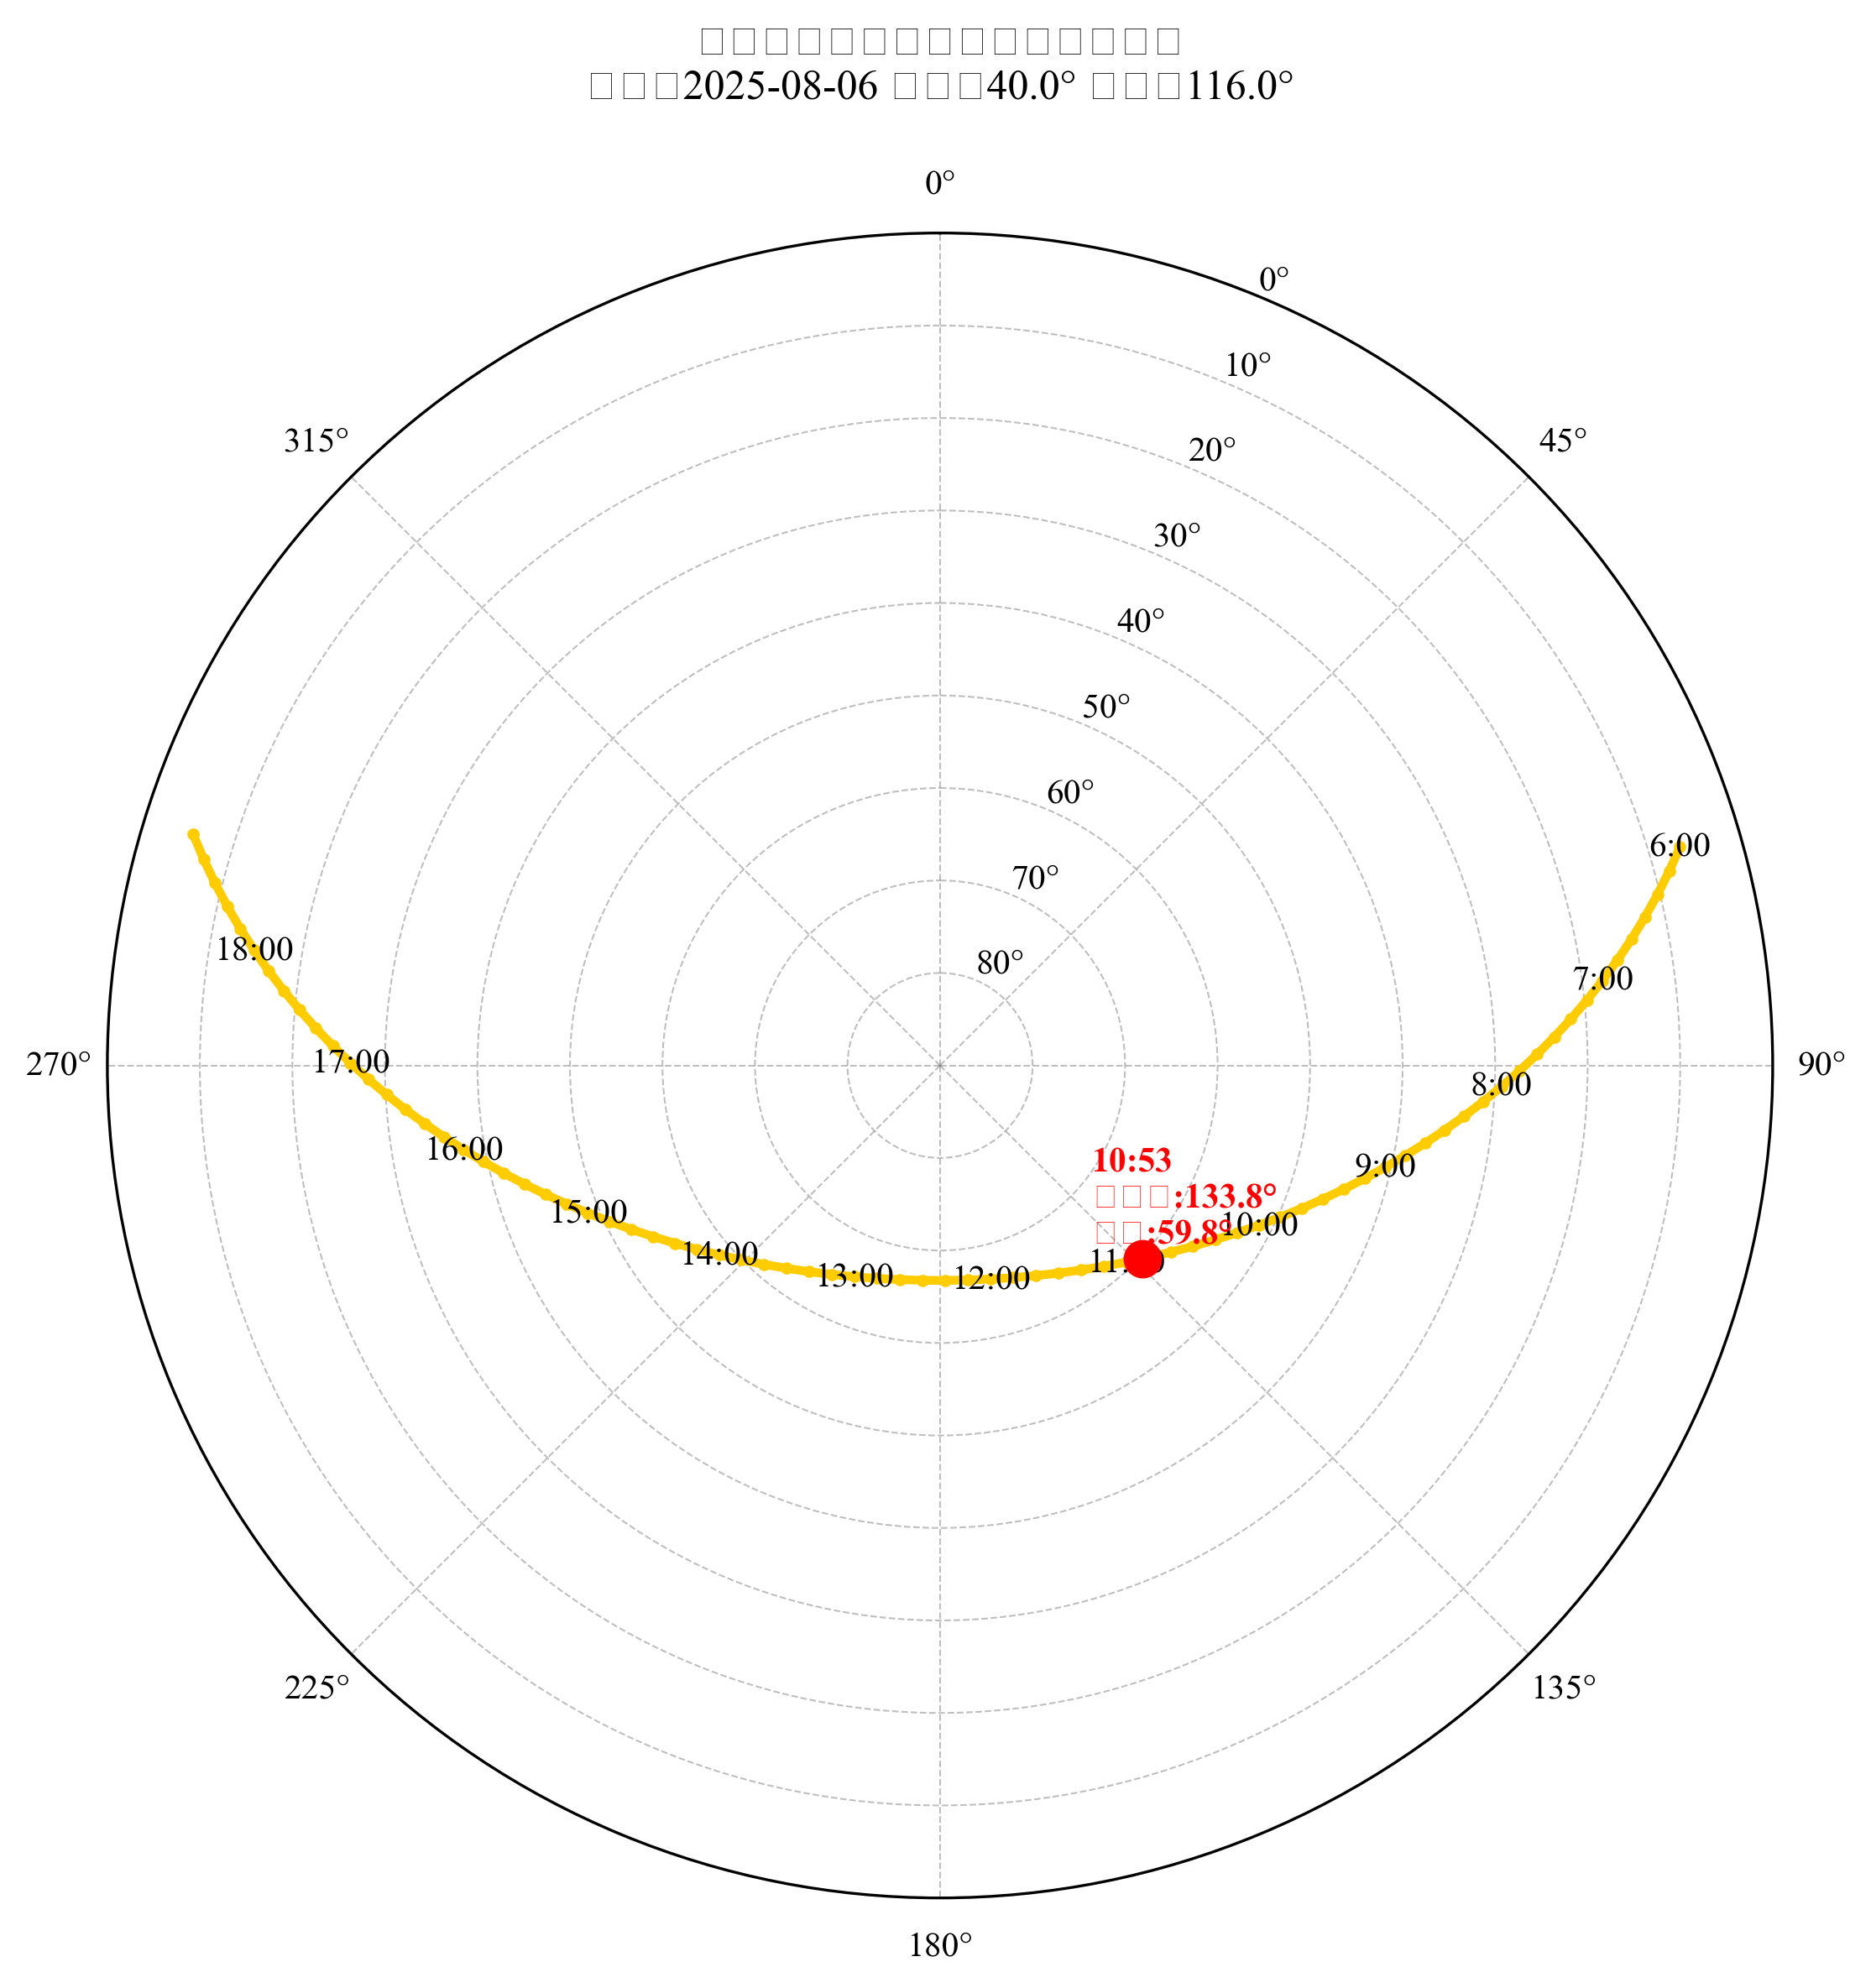

In [ ]:
import math
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import numpy as np

# ===================== 全局配置：匹配示例样式 =====================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']  # 中文显示
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (8, 8)  # 正方形画布，匹配极坐标
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['lines.color'] = '#FFCC00'  # 示例中的黄色轨迹线
plt.rcParams['font.size'] = 10

# 复用之前的太阳位置计算函数
def calculate_sun_position(date_time: datetime, lat: float, lng: float) -> dict:
    PI = math.pi
    RAD = PI / 180.0
    DAY_MS = 1000 * 60 * 60 * 24
    J1970 = 2440588.0
    J2000 = 2451545.0
    EARTH_OBLIQUITY = 23.4397 * RAD

    def to_julian(dt: datetime) -> float:
        timestamp_ms = dt.timestamp() * 1000
        return timestamp_ms / DAY_MS - 0.5 + J1970

    def to_days(dt: datetime) -> float:
        return to_julian(dt) - J2000

    def right_ascension(l: float, b: float) -> float:
        return math.atan2(math.sin(l) * math.cos(EARTH_OBLIQUITY) - math.tan(b) * math.sin(EARTH_OBLIQUITY),
                          math.cos(l))

    def declination(l: float, b: float) -> float:
        return math.asin(math.sin(b) * math.cos(EARTH_OBLIQUITY) +
                         math.cos(b) * math.sin(EARTH_OBLIQUITY) * math.sin(l))

    def azimuth(H: float, phi: float, dec: float) -> float:
        return math.atan2(math.sin(H),
                          math.cos(H) * math.sin(phi) - math.tan(dec) * math.cos(phi))

    def altitude(H: float, phi: float, dec: float) -> float:
        return math.asin(math.sin(phi) * math.sin(dec) +
                         math.cos(phi) * math.cos(dec) * math.cos(H))

    def sidereal_time(d: float, lw: float) -> float:
        return RAD * (280.16 + 360.9856235 * d) - lw

    def solar_mean_anomaly(d: float) -> float:
        return RAD * (357.5291 + 0.98560028 * d)

    def ecliptic_longitude(M: float) -> float:
        C = RAD * (1.9148 * math.sin(M) + 0.02 * math.sin(2 * M) + 0.0003 * math.sin(3 * M))
        P = RAD * 102.9372
        return M + C + P + PI

    def sun_coords(d: float) -> dict:
        M = solar_mean_anomaly(d)
        L = ecliptic_longitude(M)
        return {'dec': declination(L, 0.0), 'ra': right_ascension(L, 0.0)}

    lw = RAD * -lng
    phi = RAD * lat
    d = to_days(date_time)
    sun_c = sun_coords(d)
    H = sidereal_time(d, lw) - sun_c['ra']
    az_rad = azimuth(H, phi, sun_c['dec'])
    alt_rad = altitude(H, phi, sun_c['dec'])

    az_deg = (math.degrees(az_rad) + 180) % 360  # 修正为正北0°顺时针
    alt_deg = math.degrees(alt_rad)
    return {'azimuth': az_deg, 'altitude': alt_deg}

# 生成太阳轨迹图（匹配示例样式）
def plot_sun_path(target_date: datetime, lat: float, lng: float):
    # 1. 生成当天06:00-19:00的分钟级数据（示例中的时间范围）
    times = [target_date + timedelta(minutes=i) for i in range(6*60, 19*60, 10)]
    azimuth_list = []
    altitude_list = []
    hour_markers = {}  # 存储每小时的位置（用于标注）

    for t in times:
        pos = calculate_sun_position(t, lat, lng)
        az = pos['azimuth']
        alt = pos['altitude']
        if alt > 0:  # 只保留太阳在地平线上的数据
            azimuth_list.append(az)
            altitude_list.append(alt)
            # 记录每小时的位置（用于标注）
            hour = t.hour
            if hour not in hour_markers:
                hour_markers[hour] = (az, alt)

    # 2. 转换为极坐标（匹配示例的地平坐标系）
    # 极坐标中：theta=方位角（弧度），r=90°-仰角（表示离地高度）
    theta = np.radians(azimuth_list)
    r = 90 - np.array(altitude_list)

    # 3. 绘制极坐标图
    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    # 配置极坐标：正北为0°，顺时针旋转（匹配示例）
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)  # 顺时针
    ax.set_ylim(0, 90)  # r的范围是0（天顶）到90（地平线）
    ax.set_yticks(np.arange(10, 91, 10))  # 仰角刻度（10°间隔）
    ax.set_yticklabels([f'{90 - t}°' for t in ax.get_yticks()])  # 显示仰角（而非r值）
    ax.grid(True, linestyle='--', color='gray')

    # 绘制太阳轨迹线
    ax.plot(theta, r, color='#FFCC00', marker='.', markersize=5)

    # 4. 标注小时（如示例中的06:00、07:00等）
    for hour, (az, alt) in hour_markers.items():
        if alt > 0:
            theta_h = np.radians(az)
            r_h = 90 - alt
            ax.text(theta_h, r_h, f'{hour}:00', fontsize=10, ha='center', va='center')

    # 5. 标注当前时间（示例中的10:53）
    current_time = datetime(target_date.year, target_date.month, target_date.day, 10, 53)
    current_pos = calculate_sun_position(current_time, lat, lng)
    current_theta = np.radians(current_pos['azimuth'])
    current_r = 90 - current_pos['altitude']
    ax.scatter(current_theta, current_r, color='red', s=100, zorder=5)  # 红色太阳标记
    ax.text(current_theta + 0.1, current_r - 5, 
            f'10:53\n方位角:{current_pos["azimuth"]:.1f}°\n仰角:{current_pos["altitude"]:.1f}°',
            color='red', fontweight='bold')

    # 6. 标题与布局（匹配示例）
    plt.title(f'互动版太阳路径图（坐标：地平）\n日期：{target_date.strftime("%Y-%m-%d")} 纬度：{lat}° 经度：{lng}°',
              fontsize=12, pad=20)
    plt.tight_layout()
    plt.show()

# ===================== 运行：匹配示例的条件 =====================
if __name__ == "__main__":
    TARGET_DATE = datetime(2025, 8, 6)  # 示例中的日期
    TARGET_LAT = 40.0  # 示例中的纬度
    TARGET_LNG = 116.0  # 示例中的经度
    plot_sun_path(TARGET_DATE, TARGET_LAT, TARGET_LNG)